# Load data

In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

base_path = "/Users/sekemiadenuga/Documents/Dissertation/Data"

time_map = {
    "60sec_preseizure": "60s Pre-ictal",
    "30sec_preseizure": "30s Pre-ictal",
    "5sec_preseizure": "5s Pre-ictal",
    "5sec_of_seizure": "Ictal (5s)"
}

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 100),
}

def get_files(folder):
    return [f for f in os.listdir(folder) if f.endswith(".npy")]

## Heatmap

In [5]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# File path
base_path = "/Users/sekemiadenuga/Documents/Dissertation/Data"

# Timepoint
time_map = {
    "60sec_preseizure": "60s Pre-ictal",
    "30sec_preseizure": "30s Pre-ictal",
    "5sec_preseizure": "5s Pre-ictal",
    "5sec_of_seizure": "Ictal (5s)"
}

# Assign Frequency bands
bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 100),
}

# Load data
def get_files(folder):
    return [f for f in os.listdir(folder) if f.endswith(".npy")]

all_data = []

for folder, display_name in time_map.items():
    folder_path = os.path.join(base_path, folder)

    for file in get_files(folder_path):

        data = np.load(os.path.join(folder_path, file))  
        # shape: (83 seizures, 50 freq bins)

        animal_id = file.split('_')[0]

        freqs = np.linspace(0, 100, data.shape[1])

        for band_name, (fmin, fmax) in bands.items():

            idx = (freqs >= fmin) & (freqs <= fmax)

            # average across frequency, KEEP seizures × channels
            band_values = np.nanmean(data[:, idx], axis=1)  
            # shape: (83 seizures,)

            for seizure_idx, gc_val in enumerate(band_values):

                all_data.append({
                    "Animal_ID": animal_id,
                    "Timepoint": display_name,
                    "Band": band_name,
                    "Seizure": seizure_idx,
                    "GC": gc_val
                })

# Create dataframe
df = pd.DataFrame(all_data)

print(df.head())

  Animal_ID      Timepoint   Band  Seizure        GC
0       109  60s Pre-ictal  delta        0  0.469347
1       109  60s Pre-ictal  delta        1  0.724212
2       109  60s Pre-ictal  delta        2  0.025541
3       109  60s Pre-ictal  delta        3  1.818116
4       109  60s Pre-ictal  delta        4  0.098272


## Create heatmap for Timepoint and Frequency band average

In [6]:
# Average within animals
animal_level = df.groupby(
    ["Animal_ID", "Timepoint", "Band"]
)["GC"].mean().reset_index()

# Average across animals
df_avg = animal_level.groupby(
    ["Timepoint", "Band"]
)["GC"].mean().reset_index()

# Order the time-windows
time_order = [
    "60s Pre-ictal",
    "30s Pre-ictal",
    "5s Pre-ictal",
    "Ictal (5s)"
]

band_order = ["delta", "theta", "alpha", "beta", "gamma"]

df_avg["Timepoint"] = pd.Categorical(df_avg["Timepoint"], categories=time_order, ordered=True)
df_avg["Band"] = pd.Categorical(df_avg["Band"], categories=band_order, ordered=True)

In [7]:
# Colour scheme
colors = ["navy", "purple", "pink", "firebrick"]
custom_cmap = LinearSegmentedColormap.from_list("custom_heat", colors)

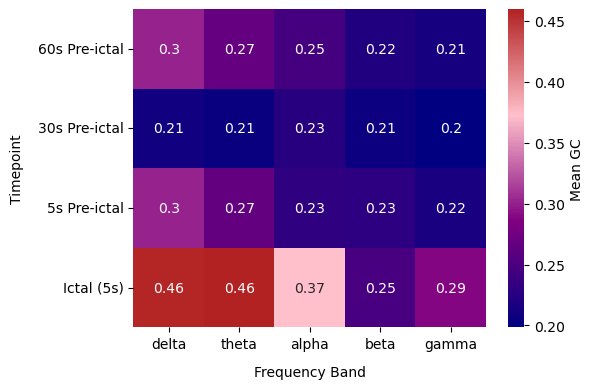

In [8]:
# Plot
heatmap_data = df_avg.pivot(
    index="Timepoint",
    columns="Band",
    values="GC"
).sort_index()

plt.figure(figsize=(6, 4))

sns.heatmap(
    heatmap_data,
    cmap=custom_cmap,
    annot=True,
    cbar_kws={'label': 'Mean GC'}
)

plt.rcParams['font.family'] = 'Arial'
plt.xlabel("Frequency Band", labelpad = 10)
plt.ylabel("Timepoint", labelpad = 10)
plt.tight_layout()
plt.show()